#### Transfer Learning
Implement transfer learning using a small network like Mobilenetv2 pretrained on
standard dataset like ImageNet, which will be relatively quick to train. But note, you
may have to resize the speech data to fit the input size of Mobilenetv2. Compare
performance to the best model from Task 2 and your baseline model.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,
import torch.optim as optim #Optimization module
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import torchvision
from torchvision import datasets, models
from torchvision.transforms import v2 as transforms
from torchvision.ops import Conv2dNormActivation

from torchaudio.transforms import FrequencyMasking, TimeMasking

from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sn

import matplotlib.pyplot as plt
import numpy as np
import random
import time
import warnings
import os
from tqdm import tqdm

import pandas as pd
%matplotlib inline
warnings.filterwarnings("ignore")

In [4]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [149]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 128
    num_epochs: int = 50
    learning_rate: float = 1e-3

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./speechImageData/speechImageData - Copy/"
    num_workers: int = 4 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Load Custom data available in Pytorch

In [150]:
train_root = os.path.join(train_config.data_root, "TrainData")
val_root = os.path.join(train_config.data_root, "ValData")

#### Data Preprocessing

In [153]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

img_size = (98, 50)

preprocess = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [154]:
common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

train_transforms = transforms.Compose([
    preprocess,
    transforms.RandomApply([
        TimeMasking(time_mask_param=10),
        FrequencyMasking(freq_mask_param=5)
    ],p=0.9),
    transforms.Normalize(mean,std)
])

#### Data Loader Preparation

In [155]:
train_data = datasets.ImageFolder(root= train_root, transform=train_transforms)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

train_data.classes

['background',
 'down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'unknown',
 'up',
 'yes']

In [156]:
#Load all the data
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers 
)

#### Load the Mobilenetv2 Pre-Trained Model

In [157]:
mobilenet_v2 = models.mobilenet_v2(weights="DEFAULT")
mobilenet_v2 = mobilenet_v2.to(DEVICE)

In [158]:
for param in mobilenet_v2.parameters():
    param.requires_grad = False

#### Unfreeze the classifier head

In [171]:
fc_input = 1280
num_classes = 12

mobilenet_v2.classifier = nn.Sequential(
    nn.Linear(in_features=fc_input, out_features=128),
    nn.ReLU(),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(in_features=64, out_features=num_classes)
)

#### Display Images from the Dataset

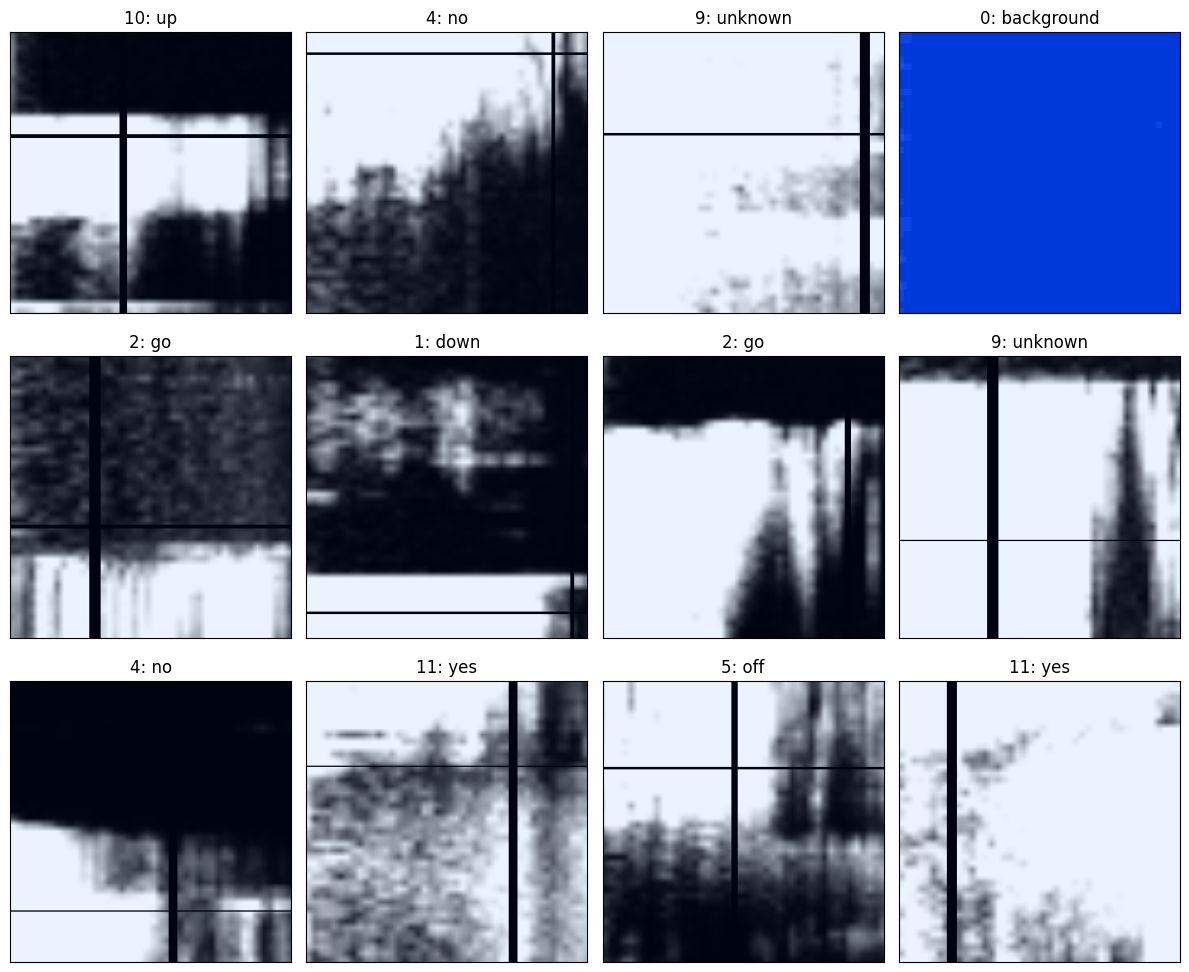

In [172]:
def visualize_images(trainloader, number_of_images=12):
    fig = plt.figure(figsize=(12,10))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image.permute(1,2,0))

        ax.set_title(f"{label.item()}: {train_data.classes[label.item()]}")

    fig.tight_layout()

    plt.savefig("time_frequency_masking.pdf", dpi=600, bbox_inches="tight")
    plt.show()
visualize_images(train_loader)

#### Model Training and Evaluation

In [173]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [174]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [175]:
optimizer = torch.optim.Adam(mobilenet_v2.parameters(), lr= train_config.learning_rate, weight_decay=.01)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,98,50)

print(summary(mobilenet_v2, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                       Output Shape              Param #
MobileNetV2 (MobileNetV2)                     [1, 12]                   --
├─Sequential (features)                       [1, 1280, 4, 2]           --
│    └─Conv2dNormActivation (0)               [1, 32, 49, 25]           --
│    │    └─Conv2d (0)                        [1, 32, 49, 25]           (864)
│    │    └─BatchNorm2d (1)                   [1, 32, 49, 25]           (64)
│    │    └─ReLU6 (2)                         [1, 32, 49, 25]           --
│    └─InvertedResidual (1)                   [1, 16, 49, 25]           --
│    │    └─Sequential (conv)                 [1, 16, 49, 25]           (896)
│    └─InvertedResidual (2)                   [1, 24, 25, 13]           --
│    │    └─Sequential (conv)                 [1, 24, 25, 13]           (5,136)
│    └─InvertedResidual (3)                   [1, 24, 25, 13]           --
│    │    └─Sequential (conv)                 [1, 24, 25, 13]           (8,832)
│ 

In [177]:
def main(model, trainloader, val_loader, DEVICE='cpu'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "transfer_best.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [188]:
train_losses, val_losses, train_accuracies, val_accuracies = main(mobilenet_v2, train_loader, val_loader, 'cpu')

Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:33<00:00,  3.39s/it]


Epoch 1 - Train loss: 1.6001832783222198 Train accuracy: 45.227386306846576 %%% Val loss: 2.131310296058655 Val accuracy: 25.19214346712212
Saving the model... 


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:34<00:00,  3.46s/it]


Epoch 2 - Train loss: 1.631199948489666 Train accuracy: 44.8775612193903 %%% Val loss: 2.078020167350769 Val accuracy: 28.949615713065757
Saving the model... 


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:32<00:00,  3.23s/it]


...

Epoch 48 - Train loss: 1.5371747836470604 Train accuracy: 46.72663668165917 %%% Val loss: 2.053801918029785 Val accuracy: 29.120409906063195


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:27<00:00,  2.71s/it]


Epoch 49 - Train loss: 1.4959230720996857 Train accuracy: 49.72513743128436 %%% Val loss: 2.0944052815437315 Val accuracy: 27.66865926558497


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:26<00:00,  2.60s/it]

Epoch 50 - Train loss: 1.4970135986804962 Train accuracy: 49.075462268865564 %%% Val loss: 2.077629566192627 Val accuracy: 28.266438941076004


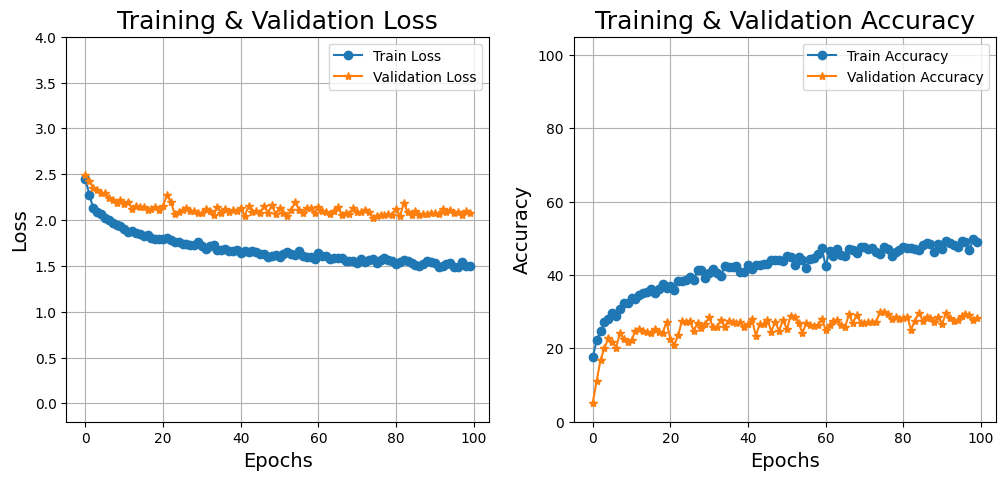

In [202]:
FONT_SIZE = 14
TITLE_SIZE = 18
X_LABEL_SIZE = 14
Y_LABEL_SIZE = 14
LEGEND_SIZE = 10


PLOT_FILE = "task_3_transfer_learning.pdf"

plt.figure(figsize=[12,5])

plt.subplot(1,2,1)
plt.plot(range(0,len(train_losses_overall)), train_losses_overall, label="Train Loss", marker='o')
plt.plot(range(0,len(train_losses_overall)), val_losses_overall, label="Validation Loss", marker='*')

plt.ylim([-0.2,4])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Loss", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Loss", fontsize=TITLE_SIZE)
plt.grid()

plt.legend()

plt.subplot(1,2,2)
plt.plot(range(0,len(train_accuracies_overall)), train_accuracies_overall, label="Train Accuracy", marker='o')
plt.plot(range(0,len(val_accuracies_overall)), val_accuracies_overall, label="Validation Accuracy", marker='*')

plt.ylim([0,105])
plt.xlabel("Epochs", fontsize=X_LABEL_SIZE)
plt.ylabel("Accuracy", fontsize=Y_LABEL_SIZE)
plt.title("Training & Validation Accuracy", fontsize=TITLE_SIZE)

plt.legend()

plt.grid()

plt.savefig(PLOT_FILE, dpi=600, bbox_inches="tight")

In [124]:
for parm in mobilenet_v2.parameters():
    param.requires_grad = False

In [125]:
for param in mobilenet_v2.classifier.parameters():
    param.requires_grad = True

In [179]:
train_loader.batch_size

128

In [200]:
val_losses_overall = []
train_losses_overall = []

train_accuracies_overall = []
val_accuracies_overall = []

for val in overall_val_losses[0]:
    val_losses_overall.append(val)

for val in val_losses:
    val_losses_overall.append(val)

for val in overall_val_accuracies[0]:
    val_accuracies_overall.append(val)

for val in val_accuracies:
    val_accuracies_overall.append(val)
    

for train in overall_train_losses[0]:
    train_losses_overall.append(train)

for train in train_losses:
    train_losses_overall.append(train)

for train in overall_train_accuracies[0]:
    train_accuracies_overall.append(train)

for train in train_accuracies:
    train_accuracies_overall.append(train)